# Grid Cell Scorer — notebook version

Cell-by-cell version of `grid_cell_scorer.py` so each stage of the pipeline
(load data -> occupancy map -> firing rate map -> autocorrelation ->
hexagonal gridness score -> shuffle significance test -> batch over all
neurons) can be run and inspected individually.

The underlying logic is unchanged from `grid_cell_scorer.py` — this notebook
only splits it into cells and replaces the CLI (`argparse`) entry point with
a "set your paths here" cell.


In [57]:
from __future__ import annotations

import gc
import json
import math
import pickle
from pathlib import Path
from typing import Dict, List, Mapping, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage, signal

%matplotlib inline

## Configuration

In [58]:
DEFAULT_LAYER_ORDER = ["d1", "z1", "d2", "z2", "d3", "z3", "d4"]
DEFAULT_NUM_SHUFFLES = 20

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

## MATLAB-style Gaussian kernel

Matches MATLAB's `fspecial('gaussian', shape, sigma)`, used to smooth the occupancy and firing-rate maps.

In [59]:
def matlab_style_gauss2d(shape: Sequence[int], sigma: float) -> np.ndarray:
    """Match MATLAB fspecial('gaussian', shape, sigma)."""
    m, n = [(ss - 1.0) / 2.0 for ss in shape]
    y, x = np.ogrid[-m : m + 1, -n : n + 1]
    h = np.exp(-((x * x + y * y) / (2.0 * sigma * sigma)))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h

## Data loading

Loads the trajectory (x, y positions over time) and the neuron activations
(per-layer arrays keyed by `D1, D2, D3, LEC, MEC, graph_LEC, graph_MEC`),
and aligns the two so activations[t] corresponds to pos[t].

In [60]:
def load_pickle(path):
    path = Path(path)
    with path.open("rb") as handle:
        return pickle.load(handle)



def load_trajectory(traj_path):

    data = load_pickle(traj_path)

    if "ground_truth" not in data:
        raise ValueError("ground_truth not found in pickle.")

    traj = np.asarray(data["ground_truth"], dtype=float)

    # remove first 50 timesteps
    traj = traj[:, 50:, :]



    return traj

def align_positions_to_time(pos: np.ndarray, time_len: int) -> np.ndarray:
    
    if len(pos) == time_len:
        return pos
    if len(pos) == time_len + 1:
        return pos[:-1]
    if len(pos) == time_len - 1:
        raise ValueError(
            f"Trajectory is shorter than activations: {len(pos)} vs {time_len}"
        )
    raise ValueError(
        f"Could not align trajectory length {len(pos)} with activation length {time_len}"
    )


def _transpose_if_needed(arr: np.ndarray, time_len: int) -> np.ndarray:
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D activations, got shape {arr.shape}")
    if arr.shape[0] == time_len:
        return arr
    if arr.shape[1] == time_len:
        return arr.T
    raise ValueError(
        f"Could not align activation shape {arr.shape} with trajectory length {time_len}"
    )


def load_activations(
    activations_path,
    layer_order=DEFAULT_LAYER_ORDER,
):

    data = load_pickle(activations_path)

    activations = {}
    neuron_meta = {}

    for layer in layer_order:

        if layer not in data:
            continue

        arr = np.abs(np.asarray(data[layer]))

        # remove first 50 timesteps
        arr = arr[:, 50:, :]

        activations[layer] = arr

        neuron_meta[layer] = list(range(arr.shape[2]))

    return activations, neuron_meta


## Occupancy map

How much time the agent spent in each spatial bin, Gaussian-smoothed and normalized to a probability distribution.

In [61]:
def occupancy_map_func(
    pos: np.ndarray,
    reso: int = 40,
    win_len: int = 9,
    sigma: float = 3.0,
) -> np.ndarray:
    hist, _, _ = np.histogram2d(pos[:, 0], pos[:, 1], bins=reso*2)
    gaussian = matlab_style_gauss2d([win_len, win_len], sigma)
    pos_prob = signal.convolve2d(gaussian, hist)
    trim = int(win_len / 2)
    pos_prob = pos_prob[trim:-trim, trim:-trim]
    pos_prob = pos_prob / np.nansum(pos_prob)

    return pos_prob

## Firing rate map

Thresholds a neuron's response (mean + `thresh_param` * std), bins high-firing timesteps by position, normalizes by occupancy, and smooths.

In [62]:
def build_firing_rate_map(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray | None = None,
    thresh_param: float = 1.5,
    res_param: int = 40,
    gaussian_shape: Sequence[int] = (9, 9),
    gaussian_sigma: float = 3.0,
    normalization: str = "occupancy",
):

    bins = res_param * 2

    # Threshold activity
    threshold = responses.mean() + thresh_param * responses.std()

    active = responses.copy()
    active[active < threshold] = 0

    xmin, xmax = pos[:,0].min(), pos[:,0].max()
    ymin, ymax = pos[:,1].min(), pos[:,1].max()

    # Sum activity in each spatial bin
    activity_map, xedges, yedges = np.histogram2d(
        pos[:,0],
        pos[:,1],
        bins=bins,
        range=[[xmin,xmax],[ymin,ymax]],
        weights=active,
    )

    # Occupancy counts
    if occupancy_map is None:

        occupancy_map, _, _ = np.histogram2d(
            pos[:,0],
            pos[:,1],
            bins=bins,
            range=[[xmin,xmax],[ymin,ymax]],
        )

    gaussian = matlab_style_gauss2d(gaussian_shape, gaussian_sigma)

    activity_map = signal.convolve2d(
        activity_map,
        gaussian,
        mode="same",
    )

    occupancy_map = signal.convolve2d(
        occupancy_map,
        gaussian,
        mode="same",
    )

    with np.errstate(divide="ignore", invalid="ignore"):

        firing_map = activity_map / occupancy_map

    firing_map[np.isnan(firing_map)] = 0
    firing_map[np.isinf(firing_map)] = 0

    extent = [xmin, xmax, ymin, ymax]

    return firing_map.T, extent

## Spatial autocorrelation

Builds the spatial autocorrelogram of a firing-rate map (Pearson correlation at every 2D lag offset).

In [63]:
def point_corr(
    map1: np.ndarray,
    map2: np.ndarray,
    row_off: int,
    col_off: int,
    bins: int,
) -> float:
    num_rows = bins - abs(row_off)
    num_cols = bins - abs(col_off)

    if row_off > 0:
        r_st1 = abs(row_off)
        r_st2 = 0
    else:
        r_st1 = 0
        r_st2 = abs(row_off)

    if col_off > 0:
        c_st1 = abs(col_off)
        c_st2 = 0
    else:
        c_st1 = 0
        c_st2 = abs(col_off)

    block1 = map1[r_st1 : r_st1 + num_rows, c_st1 : c_st1 + num_cols]
    block2 = map2[r_st2 : r_st2 + num_rows, c_st2 : c_st2 + num_cols]
    valid = ~np.isnan(block1) & ~np.isnan(block2)
    nb = int(valid.sum())
    if nb < 20:
        return 0.0

    x = block1[valid]
    y = block2[valid]
    sum_x = x.sum()
    sum_y = y.sum()
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x * x)
    sum_y2 = np.sum(y * y)

    var_x = sum_x2 - (sum_x * sum_x) / nb
    var_y = sum_y2 - (sum_y * sum_y) / nb
    cov_xy = sum_xy - (sum_x * sum_y) / nb

    if (var_x <= 0 <= var_y) or (var_y <= 0 <= var_x):
        return 0.0
    if var_x <= 0 or var_y <= 0:
        return 0.0

    return float(cov_xy / math.sqrt(var_x * var_y))


def correlation_map(map1: np.ndarray, map2: np.ndarray) -> np.ndarray:
    bins = map1.shape[0]
    n = bins + round(0.64 * bins)
    if n % 2 == 0:
        n -= 1
    center_bin = (n + 1) // 2

    corr = np.zeros((n, n), dtype=float)
    for ii in range(n):
        row_off = ii + 1 - center_bin
        for jj in range(n):
            col_off = jj + 1 - center_bin
            corr[ii, jj] = point_corr(map1, map2, row_off, col_off, bins)
    return corr


def _crop_center(rotated: np.ndarray, target_shape: Tuple[int, int]) -> np.ndarray:
    start0 = (rotated.shape[0] - target_shape[0]) // 2
    start1 = (rotated.shape[1] - target_shape[1]) // 2
    return rotated[start0 : start0 + target_shape[0], start1 : start1 + target_shape[1]]


def corrcoef2(a: np.ndarray, b: np.ndarray) -> float:
    a_flat = np.asarray(a, dtype=float).ravel()
    b_flat = np.asarray(b, dtype=float).ravel()
    valid = ~np.isnan(a_flat) & ~np.isnan(b_flat)
    if valid.sum() < 2:
        return 0.0
    a_flat = a_flat[valid]
    b_flat = b_flat[valid]
    if np.std(a_flat) == 0 or np.std(b_flat) == 0:
        return 0.0
    return float(np.corrcoef(a_flat, b_flat)[0, 1])

## Hexagonal gridness score (HGS)

Rotates the (ring-masked) autocorrelogram by 30/60/90/120/150 degrees and
compares it to the original. Grid cells have 60-fold rotational symmetry, so
`min(r60, r120) - max(r30, r90, r150)` is large and positive for true grid
cells.

In [64]:
def gridscore(masked_corr: np.ndarray) -> float:
    c60 = ndimage.rotate(masked_corr, 60, reshape=True)
    c60_2 = _crop_center(c60, masked_corr.shape)
    r60 = corrcoef2(masked_corr, c60_2)

    c120 = ndimage.rotate(masked_corr, 120, reshape=True)
    c120_2 = _crop_center(c120, masked_corr.shape)
    r120 = corrcoef2(masked_corr, c120_2)

    c30 = ndimage.rotate(masked_corr, 30, reshape=True)
    c30_2 = _crop_center(c30, masked_corr.shape)
    r30 = corrcoef2(masked_corr, c30_2)

    c90 = ndimage.rotate(masked_corr, 90, reshape=False)
    r90 = corrcoef2(masked_corr, c90)

    c150 = ndimage.rotate(masked_corr, 150, reshape=True)
    c150_2 = _crop_center(c150, masked_corr.shape)
    r150 = corrcoef2(masked_corr, c150_2)

    return float(min(r60, r120) - max(r30, r90, r150))

## Peak detection and ring masking

Finds the six autocorrelation peaks nearest the center, then masks the
autocorrelogram down to an annulus (ring) between an inner and outer radius
before scoring — this excludes the central peak and far-field noise.

In [65]:
def _regional_maxima(arr: np.ndarray) -> np.ndarray:
    max_filtered = ndimage.maximum_filter(arr, size=3, mode="nearest")
    return (arr == max_filtered) & np.isfinite(arr)


def get_original_grid_score(spikes_smooth: np.ndarray, win_len: int = 7) -> float:
    rotated_img = ndimage.rotate(spikes_smooth, 90, reshape=True)
    trim = round(win_len / 2)
    rotated_img = rotated_img[trim:-trim, trim:-trim]

    corr = correlation_map(rotated_img, rotated_img)
    rows, cols = corr.shape
    central_peak = np.array([0.5 * (rows + 1), 0.5 * (cols + 1)], dtype=float)

    maxima = _regional_maxima(corr)
    peakx, peaky = np.where(maxima)
    if peakx.size == 0:
        return float("nan")

    peak_matrix = np.column_stack((peakx + 1, peaky + 1))
    distances = np.linalg.norm(peak_matrix - central_peak, axis=1)
    distascending = np.sort(distances)
    if len(distascending) < 6:
        return float("nan")

    radius1 = np.max(distascending[1 : min(6, len(distascending))]) + 3
    rr, cc = np.meshgrid(np.arange(1, len(corr) + 1), np.arange(1, len(corr) + 1))
    circlemask1 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius1
    corr_ring = corr * circlemask1

    radius2 = 12
    circlemask2 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius2
    corr_ring = corr_ring * (~circlemask2)

    return gridscore(corr_ring)


def build_autocorrelation_ring(
    spikes_smooth: np.ndarray,
    win_len: int = 7,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rotated_img = ndimage.rotate(spikes_smooth, 90, reshape=True)
    trim = round(win_len / 2)
    rotated_img = rotated_img[trim:-trim, trim:-trim]

    corr = correlation_map(rotated_img, rotated_img)
    rows, cols = corr.shape
    central_peak = np.array([0.5 * (rows + 1), 0.5 * (cols + 1)], dtype=float)

    maxima = _regional_maxima(corr)
    peakx, peaky = np.where(maxima)
    if peakx.size == 0:
        return corr, corr, rotated_img

    peak_matrix = np.column_stack((peakx + 1, peaky + 1))
    distances = np.linalg.norm(peak_matrix - central_peak, axis=1)
    distascending = np.sort(distances)
    if len(distascending) < 6:
        return corr, corr, rotated_img

    radius1 = np.max(distascending[1 : min(6, len(distascending))]) + 3
    rr, cc = np.meshgrid(np.arange(1, len(corr) + 1), np.arange(1, len(corr) + 1))
    circlemask1 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius1
    corr_ring = corr * circlemask1

    radius2 = 12
    circlemask2 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius2
    corr_ring = corr_ring * (~circlemask2)
    return corr, corr_ring, rotated_img

## Per-neuron scoring (shuffle significance test)

For one neuron: compute the real HGS, then compute HGS on `num_shuffles`
time-shuffled versions of its activity to build a null distribution. The
neuron is called a grid cell if its real HGS exceeds the 95th percentile of
the shuffled scores.

In [66]:
def score_single_neuron(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray,
    num_shuffles: int,
    rng: np.random.Generator,
    thresh_param: float,
    res_param: int,
) -> Dict[str, object]:
    
    
    #map_res = int(occupancy_map.shape[0]) if occupancy_map is not None else res_param
    map_res = res_param
    original_map, original_extent = build_firing_rate_map(
        responses,
        pos,
        occupancy_map,
        thresh_param=thresh_param,
        res_param=map_res,
    )
    

    
    autocorr_map, autocorr_ring, _ = build_autocorrelation_ring(original_map)
    original_hgs = gridscore(autocorr_ring)

    shuffled_scores = np.zeros(num_shuffles, dtype=float)
    for shuffle_idx in range(num_shuffles):
        shuffled_resp = rng.permutation(responses)
        shuffled_map, _ = build_firing_rate_map(
            shuffled_resp,
            pos,
            occupancy_map,
            thresh_param=thresh_param,
            res_param=map_res,
        )
        _, shuffled_ring, _ = build_autocorrelation_ring(shuffled_map)
        shuffled_scores[shuffle_idx] = gridscore(shuffled_ring)

    threshold_95 = float(np.nanpercentile(shuffled_scores, 95))
    is_grid = bool(np.isfinite(original_hgs) and original_hgs > threshold_95)

    return {
        "original_hgs": float(original_hgs),
        "shuffle_threshold_95": threshold_95,
        "is_grid_cell": is_grid,
        "shuffled_hgs": shuffled_scores,
        "original_map": original_map,
        "original_extent": original_extent,
        "autocorr_map": autocorr_map,
        "autocorr_ring": autocorr_ring,
    }

## Plotting

Saves a firing-rate map + autocorrelogram figure for one neuron.

In [67]:
def save_neuron_plots(
    output_dir: str | Path,
    neuron_filename: str,
    layer_name: str,
    global_index: int,
    layer_neuron_index: int,
    firing_map: np.ndarray,
    firing_extent: Sequence[float],
    autocorr_map: np.ndarray,
    hgs: float,
    threshold_95: float,
    is_grid: bool,
) -> None:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    rotated = ndimage.rotate(firing_map, 90)
    rotated_extent = [firing_extent[2], firing_extent[3], firing_extent[0], firing_extent[1]]
    axes[0].imshow(
        rotated,
        origin="lower",
        cmap="jet",
        aspect="auto",
        extent=rotated_extent,
    )
    axes[0].set_title(f"{layer_name} #{layer_neuron_index} firing map")
    axes[0].axis("off")

    axes[1].imshow(autocorr_map, origin="lower", cmap="coolwarm", aspect="auto")
    axes[1].set_title(
        f"global #{global_index} autocorr\nHGS={hgs:.3f}, thr95={threshold_95:.3f}, grid={is_grid}"
    )
    axes[1].axis("off")

    fig.tight_layout()
    fig.savefig(output_path / f"{neuron_filename}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

## Batch scoring across all neurons

Loops over every neuron in the activation matrix, scores it, optionally
saves a plot, and checkpoints results to JSON after every neuron so a long
run can be inspected (or resumed from) mid-way.

In [68]:
def score_grid_cells(
    activations_path: str | Path,
    trajectory_path: str | Path,
    num_shuffles: int = DEFAULT_NUM_SHUFFLES,
    thresh_param: float = 1.5,
    res_param: int = 10,
    random_seed: int = 0,
    plots_dir: str | Path | None = None,
    checkpoint_output_path: str | Path | None = None,
) -> Dict[str, object]:
    raw_pos = load_trajectory(trajectory_path)

    activations, neuron_meta = load_activations(
        activations_path,
        time_len=len(raw_pos))

    pos = raw_pos


    occupancy_map = occupancy_map_func(pos, reso=res_param)
    rng = np.random.default_rng(random_seed)

    results: List[Dict[str, object]] = []
    grid_indices: List[int] = []

    iterator = range(200, 300)
    total_neurons = len(iterator)

    if tqdm is not None:
        iterator = tqdm(iterator, total=total_neurons, desc="Scoring neurons", unit="neuron")

    for neuron_idx in iterator:
        neuron_result = score_single_neuron(
            activations[:, neuron_idx],
            pos,
            occupancy_map,
            num_shuffles=num_shuffles,
            rng=rng,
            thresh_param=thresh_param,
            res_param=res_param,
        )
        meta = dict(neuron_meta[neuron_idx])
        meta.update(neuron_result)
        meta["shuffled_hgs"] = np.asarray(meta["shuffled_hgs"], dtype=float).tolist()
        neuron_prefix = "grid_neuron" if bool(meta["is_grid_cell"]) else "neuron"
        neuron_filename = f"{neuron_prefix}_{int(meta['global_index']):03d}"
        if plots_dir is not None:
            layer_plot_dir = Path(plots_dir) / str(meta["layer"])
            save_neuron_plots(
                layer_plot_dir,
                neuron_filename,
                str(meta["layer"]),
                int(meta["global_index"]),
                int(meta["layer_neuron_index"]),
                np.asarray(meta["original_map"], dtype=float),
                list(meta["original_extent"]),
                np.asarray(meta["autocorr_map"], dtype=float),
                float(meta["original_hgs"]),
                float(meta["shuffle_threshold_95"]),
                bool(meta["is_grid_cell"]),
            )
        meta["plot_filename"] = f"{str(meta['layer'])}/{neuron_filename}.png"
        meta.pop("original_map", None)
        meta.pop("original_extent", None)
        meta.pop("autocorr_map", None)
        meta.pop("autocorr_ring", None)
        results.append(meta)

        if bool(meta["is_grid_cell"]):
            grid_indices.append(int(meta["global_index"]))

        if checkpoint_output_path is not None:
            save_results(
                checkpoint_output_path,
                {
                    "grid_cell_indices": grid_indices,
                    "results": results,
                    "num_neurons": int(activations.shape[1]),
                    "num_grid_cells": int(len(grid_indices)),
                    "num_shuffles": int(num_shuffles),
                    "completed_neurons": int(neuron_idx + 1),
                },
            )

        del neuron_result
        del meta
        gc.collect()

        if tqdm is None:
            progress = ((neuron_idx + 1) / total_neurons) * 100.0
            print(
                f"\rScoring neurons: {neuron_idx + 1}/{total_neurons} ({progress:.1f}%)",
                end="",
                flush=True,
            )

    if tqdm is None and total_neurons:
        print()

    return {
        "grid_cell_indices": grid_indices,
        "results": results,
        "num_neurons": int(activations.shape[1]),
        "num_grid_cells": int(len(grid_indices)),
        "num_shuffles": int(num_shuffles),
    }

## Output helpers

Save results to JSON, create output directories, and infer default output paths from the activations filename.

In [69]:
def save_results(output_path: str | Path, payload: Mapping[str, object]) -> None:
    path = Path(output_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)


def ensure_output_dirs(
    output_path: str | Path,
    plots_dir: str | Path | None,
    layer_names: Sequence[str] = DEFAULT_LAYER_ORDER,
) -> None:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if plots_dir is None:
        return
    plots_root = Path(plots_dir)
    plots_root.mkdir(parents=True, exist_ok=True)
    for layer_name in layer_names:
        (plots_root / layer_name).mkdir(parents=True, exist_ok=True)


def default_output_paths(
    activations_path: str | Path,
    root_dir: str | Path | None = None,
) -> Tuple[Path, Path]:
    if root_dir is None:
        root_dir = Path.cwd().parent / "spatial cell results"
    activation_stem = Path(activations_path).stem
    prefixes = ("encoded_ec_hpc_", "encoded_")
    run_name = activation_stem
    for prefix in prefixes:
        if activation_stem.startswith(prefix):
            run_name = activation_stem[len(prefix) :]
            break
    if run_name.endswith("_30epochs"):
        run_name = run_name[: -len("_30epochs")]

    run_dir = Path(root_dir) / run_name
    json_path = run_dir / "grid cells" / "grid_cell_scores.json"
    plots_dir = run_dir / "firing rate maps"
    return json_path, plots_dir

---
## Run it

Set your input paths below, then run the cells that follow. This replaces
the `argparse`/CLI entry point (`main()`) from the `.py` script — in the
notebook you just edit the variables directly.

- `ACTIVATIONS_PATH`: pickle dict with layer keys (`D1, D2, D3, LEC, MEC,
  graph_LEC, graph_MEC`), or a plain `.csv`/`.npy`/`.npz` matrix
- `TRAJECTORY_PATH`: pickle dict with `x`/`y`, or `.csv`/`.txt` with x,y columns


In [70]:
import pickle

# Path to your pickle file
pkl_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-traj-results-training.pkl"

# Load dictionary
with open(pkl_path, "rb") as f:
    data = pickle.load(f)

# Check what was loaded
print(type(data))
print(data.keys())

# (Optional) Print the shapes of each entry
for key, value in data.items():
    try:
        print(f"{key}: {value.shape}")
    except AttributeError:
        print(f"{key}: {type(value)}")

<class 'dict'>
dict_keys(['time', 'ground_truth', 'prediction', 'd1', 'z1', 'd2', 'z2', 'd3', 'z3', 'd4'])
time: (500,)
ground_truth: (500, 500, 2)
prediction: (500, 500, 2)
d1: (500, 500, 100)
z1: (500, 500, 100)
d2: (500, 500, 100)
z2: (500, 500, 100)
d3: (500, 500, 100)
z3: (500, 500, 100)
d4: (500, 500, 100)


In [71]:
ACTIVATIONS_PATH = pkl_path
TRAJECTORY_PATH = pkl_path

NUM_SHUFFLES = DEFAULT_NUM_SHUFFLES   # controls per neuron for the significance test
THRESHOLD_PARAM = 0                 # std deviations above mean to count as "firing"
RESOLUTION_PARAM = 40                 # spatial binning resolution
RANDOM_SEED = 0

OUTPUT_PATH, PLOTS_DIR = default_output_paths(ACTIVATIONS_PATH)
# Or set explicit paths instead:
# OUTPUT_PATH = Path("grid_cell_scores.json")
# PLOTS_DIR = Path("firing_rate_maps")

ensure_output_dirs(OUTPUT_PATH, PLOTS_DIR)
print(f"Output JSON: {OUTPUT_PATH}")
print(f"Plots dir:   {PLOTS_DIR}")

Output JSON: /Users/ais/Desktop/2026_Summer/spatial cell results/2D-traj-results-training/grid cells/grid_cell_scores.json
Plots dir:   /Users/ais/Desktop/2026_Summer/spatial cell results/2D-traj-results-training/firing rate maps


In [72]:
TRAJECTORY_INDEX = 0
LAYER = "z2"


raw_pos = load_trajectory(TRAJECTORY_PATH)

activations, neuron_meta = load_activations(
    ACTIVATIONS_PATH
)

# Position for one trajectory
pos = raw_pos[TRAJECTORY_INDEX]

# Responses of ALL neurons in this trajectory
responses_all = activations[LAYER][TRAJECTORY_INDEX]

print(pos.shape)           # (450, 2)
print(responses_all.shape) # (450, 100)

(450, 2)
(450, 100)


In [55]:
occupancy_map = occupancy_map_func(pos)

scores = []

for neuron in range(responses_all.shape[1]):

    result = score_single_neuron(
        responses_all[:, neuron],
        pos,
        occupancy_map,
        num_shuffles=20,
        rng=np.random.default_rng(42),
        thresh_param=1.5,
        res_param=40,
    )

    scores.append({
        "Neuron": neuron,
        "Score": result["original_hgs"],
        "Rate Map": result["original_map"],
        "Grid Cell": result["is_grid_cell"],
    })

In [56]:
scores = sorted(scores, key=lambda x: x["Score"], reverse=True)


# Count significant grid cells
num_grid_cells = sum(neuron["Grid Cell"] for neuron in scores)

print(f"Number of grid cells: {num_grid_cells}/{len(scores)}")

Number of grid cells: 3/100


In [ ]:
# Sum the firing maps of the top 6 neurons
combined_map = np.zeros_like(top6[0]["Rate Map"])

for neuron in top6:
    combined_map += neuron["Rate Map"]

# Normalize for visualization
combined_map /= combined_map.max()

In [39]:
combined_autocorr = build_autocorrelation_ring(combined_map)

In [41]:
print(type(combined_autocorr))
print(len(combined_autocorr))

for i, item in enumerate(combined_autocorr):
    print(i, type(item))
    if hasattr(item, "shape"):
        print(item.shape)

<class 'tuple'>
3
0 <class 'numpy.ndarray'>
(117, 117)
1 <class 'numpy.ndarray'>
(117, 117)
2 <class 'numpy.ndarray'>
(72, 72)


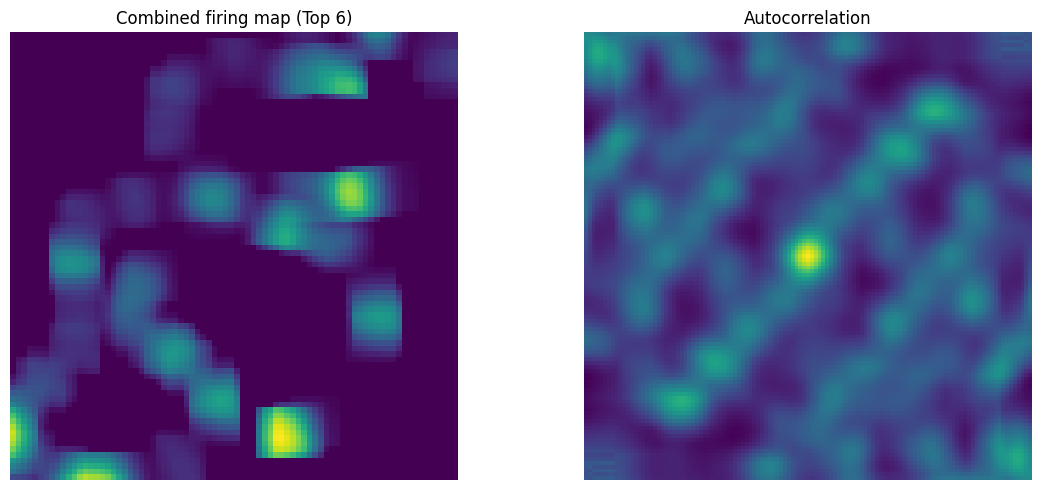

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(
    combined_map,
    origin="lower",
    cmap="viridis",
)
axes[0].set_title("Combined firing map (Top 6)")
axes[0].axis("off")

axes[1].imshow(
    combined_autocorr[0],
    origin="lower",
    cmap="viridis",
)
axes[1].set_title("Autocorrelation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

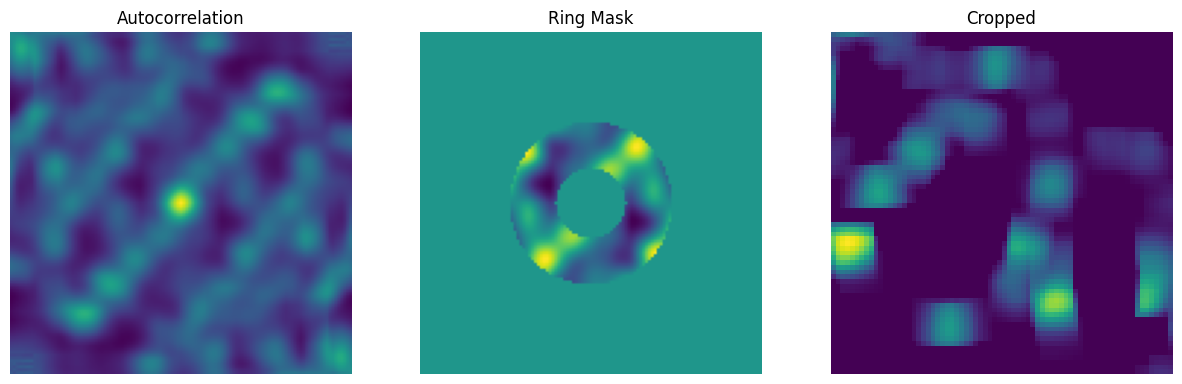

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

titles = ["Autocorrelation", "Ring Mask", "Cropped"]

for i in range(3):
    ax[i].imshow(combined_autocorr[i], origin="lower", cmap="viridis")
    ax[i].set_title(titles[i])
    ax[i].axis("off")

plt.show()

In [44]:
grid_neurons = [n for n in scores if n["Grid Cell"]]
print(len(grid_neurons))

6


### Inspect a single neuron (optional)

Useful for exploring one neuron's firing map / autocorrelogram inline
without rerunning the whole batch above.